In [1]:
import pandas as pd
import numpy as np
from datetime import datetime

# --- 1. CONFIGURACIÓN DE RUTAS ---
# Inputs
PATH_CLIENTES = r"\\compartido.lamarina.mx\Inteligencia de Clientes\ICCM\Proyectos de Inteligencia\Base de Clientes\Base de Clientes Acumulada.csv"
PATH_VENTAS = r"\\compartido.lamarina.mx\Inteligencia de Clientes\TI & Dashboards\Reporte de ventas BW\Ventas y cuentas.csv"
PATH_VFR_LM = r"\\compartido.lamarina.mx\Inteligencia de Clientes\ICCM\Proyectos de Inteligencia\P001.- VFR\Dataframes LM\Segmentos VFR.csv"
PATH_VFR_EB = r"\\compartido.lamarina.mx\Inteligencia de Clientes\ICCM\Proyectos de Inteligencia\P001.- VFR\Dataframes EB\Segmentos VFR.csv"
PATH_MOTOS_PROGRESSA = r"\\compartido.lamarina.mx\Inteligencia de Clientes\TI & Dashboards\Primera y recompra\Motos Progressa.csv"

# Outputs Finales
#OUTPUT_LM = r"\\compartido.lamarina.mx\Inteligencia de Clientes\ICCM\Proyectos de Inteligencia\P017.- Churn + Lifetime Value\Dataframes LM\Acumulado36meses-ConVariables.csv"
#OUTPUT_EB = r"\\compartido.lamarina.mx\Inteligencia de Clientes\ICCM\Proyectos de Inteligencia\P017.- Churn + Lifetime Value\Dataframes EB\Acumulado36meses-ConVariables.csv"

# Outputs Históricos (Nodos 294 y 295)
OUTPUT_HIST_LM = r"Z:\ICCM\Proyectos de Inteligencia\P017.- Churn + Lifetime Value\Dataframes LM\Historico-CompraLM.csv"
OUTPUT_HIST_EB = r"Z:\ICCM\Proyectos de Inteligencia\P017.- Churn + Lifetime Value\Dataframes EB\Historico-CompraEB.csv"

print("1/7 Cargando datos base...")
dtype_dict = {'CUENTA': str, 'NEGOCIO': str, 'Cuenta Bodegon': str}
df_clientes_raw = pd.read_csv(PATH_CLIENTES, encoding='latin1', low_memory=False, dtype=dtype_dict)
df_ventas_raw = pd.read_csv(PATH_VENTAS, encoding='latin1', low_memory=False, dtype=dtype_dict)

df_clientes_raw.columns = df_clientes_raw.columns.str.strip()
df_ventas_raw.columns = df_ventas_raw.columns.str.strip()

# --- 2. PRE-PROCESAMIENTO GLOBAL ---
df_ventas_raw['Fecha'] = pd.to_datetime(df_ventas_raw['Fecha'], errors='coerce')
max_fecha_val = df_ventas_raw['Fecha'].max()
fecha_inicio_3y = max_fecha_val - pd.DateOffset(years=3)

# --- 3. FUNCIÓN DE PROCESAMIENTO (RETORNA SUMARIZADO E HISTÓRICO) ---
def ejecutar_flujo_negocio(id_negocio):
    print(f"2/7 Procesando Negocio {id_negocio}...")
    
    # Filtro Clientes (Nodo 60/191)
    cte = df_clientes_raw.copy()
    cte['TIPOCTANUM'] = cte['TIPOCTA'].str[0]
    cte = cte[(cte['NEGOCIO'] == str(id_negocio)) & (cte['TIPOCTANUM'] != 'A')].copy()

    # Filtro Ventas (Nodo 62/193)
    vts = df_ventas_raw.copy()
    vts['Vta Total'] = pd.to_numeric(vts['Vta Total'], errors='coerce').fillna(0)
    vts['Centro'] = vts['Centro'].str[0]
    
    marcas_excluidas = ["TELCEL", "IUSACELL", "UNEFON"]
    vts = vts[
        (vts['NEGOCIO'] == str(id_negocio)) &
        (vts['Fecha'] >= fecha_inicio_3y) &
        (vts['Fecha'] <= max_fecha_val) &
        (~vts['Nombre de Marca'].isin(marcas_excluidas))
    ].copy()

    # JOIN Inicial (Nodo 63/194) -> ESTE ES EL HISTÓRICO DE COMPRA
    df_join = pd.merge(vts, cte, on='CUENTA', how='inner', suffixes=('', '_cte'))

    # SUMMARIZE (Nodo 107/279)
    group_cols = [
        'CUENTA', 'EDOCIV', 'SEXO', 'NOMCLI', 'NROCEL', 'DIASVDO', 
        'NIVEL DE ESTUDIOS', 'PUESTO', 'VALREF01', 'PRIMERA COMPRA', 
        'Dependientes economicos', 'RANGO DE EDAD', 'Salario Mensual', 
        'Codigo Postal', 'Nombre Estado', 'Garantias', 'Devoluciones', 
        'PAGO', 'MORA ACUMULADO', 'MONTO FINANCIERO', 'GASTOS DE COBRANZA', 
        'C', 'Cantidad cambios cap pago', 'Calificacion Cliente', '% Redencion'
    ]
    actual_groups = [c for c in group_cols if c in df_join.columns]

    df_summarize = df_join.groupby(actual_groups).agg(
        Monto_total=('Vta Total', 'sum'),
        Frecuencia=('Fecha', 'nunique'),
        Ultima_fecha=('Fecha', 'max'),
        Primera_fecha=('Fecha', 'min'),
        Tickets=('TRANMOV', 'nunique'),
        CRMs=('TIPOPROM', 'count'),
        Gpo_Dist=('Gpo de Artículo', 'nunique'),
        Dept_Dist=('Departamento', 'nunique'),
        Marca_Dist=('Nombre de Marca', 'nunique'),
        Last_Tienda=('Tienda', 'last'),
        CAPPAGO=('CAPPAGO', 'last'),
        CAPPADIS=('CAPPADIS', 'last'),
        CAPPADISE=('CAPPADISE', 'last'),
        TIPOCTA=('TIPOCTA', 'last')
    ).reset_index()

    df_summarize = df_summarize.rename(columns={
        'Monto_total': 'Monto total',
        'Ultima_fecha': 'Última fecha: Fecha',
        'Primera_fecha': 'Primera fecha compra',
        'Tickets': 'Numero Tickets',
        'CRMs': 'Numero de CRMs',
        'Gpo_Dist': 'Grupo de Articulos Distintos',
        'Dept_Dist': 'Grupo de Departamentos Distintos',
        'Marca_Dist': 'Marcas Distintas'
    })

    # FORMULAS
    df_summarize['Ticket Promedio'] = df_summarize['Monto total'] / df_summarize['Numero Tickets'].replace(0, np.nan)
    df_summarize['Porcentaje CRMS'] = df_summarize['Numero de CRMs'] / df_summarize['Frecuencia'].replace(0, np.nan)
    
    diff_days = (df_summarize['Última fecha: Fecha'] - df_summarize['Primera fecha compra']).dt.days
    df_summarize['Dias promedio entre compras'] = np.where(df_summarize['Frecuencia'] > 1, diff_days / (df_summarize['Frecuencia'] - 1), 0)
    df_summarize['Frescura'] = (max_fecha_val - df_summarize['Última fecha: Fecha']).dt.days
    df_summarize['Periodo'] = diff_days

    # PREFERENCIAS
    def get_top_pref(df_src, col_name, new_name):
        counts = df_src.groupby(['CUENTA', col_name]).size().reset_index(name='n')
        totals = df_src.groupby('CUENTA').size().reset_index(name='t')
        merged = pd.merge(counts, totals, on='CUENTA')
        merged[new_name] = merged['n'] / merged['t']
        return merged.sort_values(['CUENTA', 'n'], ascending=[True, False]).groupby('CUENTA').head(1)[['CUENTA', col_name, new_name]]

    df_summarize = df_summarize.merge(get_top_pref(df_join, 'Departamento', 'Porcentaje Ocurrencia Dept'), on='CUENTA', how='left')
    df_summarize = df_summarize.merge(get_top_pref(df_join, 'Gpo de Artículo', 'Porcentaje de Ocurrencia Gpo Art'), on='CUENTA', how='left')
    df_summarize = df_summarize.merge(get_top_pref(df_join, 'Nombre de Marca', 'Porcentaje de Ocurrencia Marca'), on='CUENTA', how='left')

    return df_summarize, df_join

# --- 4. EJECUCIÓN ---
df_lm, hist_lm = ejecutar_flujo_negocio(1)
df_eb, hist_eb = ejecutar_flujo_negocio(5)

# Lógica Motos Progressa EB
# print("3/7 Cruzando Motos Progressa...")
# df_motos = pd.read_csv(PATH_MOTOS_PROGRESSA, encoding='latin1', dtype={'Cuenta Bodegon': str})
# df_motos['Promedio de MONTO ORIGINAL'] = pd.to_numeric(df_motos['Promedio de MONTO ORIGINAL'], errors='coerce').fillna(0)
# df_eb = pd.merge(df_eb, df_motos[['Cuenta Bodegon', 'Promedio de MONTO ORIGINAL']], left_on='CUENTA', right_on='Cuenta Bodegon', how='left')
# df_eb['Monto total'] = df_eb['Monto total'].fillna(0) #+ df_eb['Promedio de MONTO ORIGINAL'].fillna(0)

# --- 5. CRUCE VFR E IMPUTACIONES ---
# def enriquecer_final(df_sum, path_vfr):
#     print(f"4/7 Enriqueciendo datos desde {path_vfr}...")
#     df_vfr = pd.read_csv(path_vfr, encoding='latin1', low_memory=False, dtype={'CUENTA': str})
#     df_vfr.columns = df_vfr.columns.str.strip()
    
#     cols_vfr_posibles = ['CUENTA', 'Tipo_Cliente', 'Segmento_RFM', 'Calificacion_Segmento', 'Subgrupo']
#     cols_vfr_reales = [c for c in cols_vfr_posibles if c in df_vfr.columns]
    
#     validos = ["Clientes leales", "Clientes en riesgo", "Clientes perdidos", "Clientes inactivos"]
#     df_vfr = df_vfr[df_vfr['Tipo_Cliente'].isin(validos)].copy()
    
#     df_final = pd.merge(df_sum, df_vfr[cols_vfr_reales], on='CUENTA', how='inner')
#     df_final['PRIMERA COMPRA'] = pd.to_datetime(df_final['PRIMERA COMPRA'], errors='coerce')
#     df_final['Antiguedad'] = (df_final['Última fecha: Fecha'] - df_final['PRIMERA COMPRA']).dt.days
    
#     np.random.seed(42)
#     mask_est = df_final['NIVEL DE ESTUDIOS'].isin(['SINDATO', 'INDEFINIDO']) | df_final['NIVEL DE ESTUDIOS'].isna()
#     df_final.loc[mask_est, 'NIVEL DE ESTUDIOS'] = np.random.choice(['LICENCIATURA', 'BACHILLERATO'], size=mask_est.sum(), p=[0.2, 0.8])
    
#     df_final['PUESTO'] = df_final['PUESTO'].replace('INDEFINIDO', 'EMPLEO EN GENERAL').fillna('EMPLEO EN GENERAL')
#     df_final['Salario Mensual'] = pd.to_numeric(df_final['Salario Mensual'], errors='coerce')
#     df_final['Salario Mensual'] = df_final['Salario Mensual'].fillna(df_final['Salario Mensual'].median())
    
#     for col in ['Garantias', 'Devoluciones']:
#         if col in df_final.columns:
#             df_final[col] = pd.to_numeric(df_final[col], errors='coerce').fillna(0).astype(int)
    
#     return df_final

# df_lm_final = enriquecer_final(df_lm, PATH_VFR_LM)
# df_eb_final = enriquecer_final(df_eb, PATH_VFR_EB)

# --- 6. GUARDAR HISTÓRICOS (NODOS 294 Y 295) ---
print("5/7 Guardando Históricos de Compra (Z:)...")
hist_save_cfg = {'index': False, 'encoding': 'latin1', 'lineterminator': '\r\n'}
hist_lm.to_csv(OUTPUT_HIST_LM, **hist_save_cfg)
hist_eb.to_csv(OUTPUT_HIST_EB, **hist_save_cfg)

# --- 7. GUARDAR RESULTADOS FINALES ---
print("6/7 Guardando resultados consolidados...")
#df_lm_final.to_csv(OUTPUT_LM, **hist_save_cfg)
#df_eb_final.to_csv(OUTPUT_EB, **hist_save_cfg)

print("7/7 ¡Proceso completado exitosamente en red y unidad Z!")

1/7 Cargando datos base...


2/7 Procesando Negocio 1...


2/7 Procesando Negocio 5...


5/7 Guardando Históricos de Compra (Z:)...


6/7 Guardando resultados consolidados...
7/7 ¡Proceso completado exitosamente en red y unidad Z!


# Modelo de Abandono LM

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, 
                           roc_auc_score, accuracy_score, f1_score,
                           roc_curve, precision_recall_curve, auc)
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
from tqdm import tqdm
warnings.filterwarnings('ignore')
from joblib import Parallel, delayed
import multiprocessing
import shap

# --- Cargar datos y preprocesamiento inicial ---
in_path = r'.\Dataframes LM\Historico-CompraLM.csv'
df = pd.read_csv(in_path, encoding='latin-1', low_memory=False)

# Parseo de fechas
for date_col in ['Fecha', 'Max_Fecha', 'PRIMERA COMPRA']:
    if date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

# Convertir columnas object a numéricas si es posible
for col in df.columns:
    if df[col].dtype == 'object':
        tmp = df[col].astype(str).str.replace('%', '', regex=False).str.replace(',', '', regex=False)
        coerced = pd.to_numeric(tmp, errors='coerce')
        if coerced.notna().sum() > 0:
            df[col] = coerced

# Rellenar nulos
num_cols = df.select_dtypes(include=['number']).columns.tolist()
for c in num_cols:
    if df[c].isnull().any():
        mean_val = df[c].mean()
        df[c].fillna(mean_val, inplace=True)

obj_cols = df.select_dtypes(include=['object']).columns.tolist()
for c in obj_cols:
    if df[c].isnull().any():
        mode_series = df[c].mode(dropna=True)
        if not mode_series.empty:
            mode_val = mode_series.iloc[0]
            df[c].fillna(mode_val, inplace=True)
        else:
            df[c].fillna('missing', inplace=True)

# 1. PREPROCESAMIENTO INICIAL
print("1. PREPROCESAMIENTO INICIAL")

categorical_cols = ['EDOCIV', 'SEXO', 'NIVEL DE ESTUDIOS', 'PUESTO', 'TIPO EMPLEO', 
                   'TIPOCTANUM', 'RANGO DE EDAD', 'Departamento', 'Gpo de Artículo']

label_encoders = {}
for col in categorical_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

# 2. DEFINICIÓN DE VENTANAS TEMPORALES (CORREGIDO)
print("2. DEFINICIÓN DE VENTANAS TEMPORALES")

df = df.sort_values(['CUENTA', 'Fecha'])
observation_window_months = 12 
prediction_window_months = 9 

observation_window_days = observation_window_months * 30
prediction_window_days = prediction_window_months * 30

# --- NUEVA LÓGICA DE SELECCIÓN DE VENTANAS ---
n_ventanas_deseadas = 45  # <--- AQUÍ ELIGES EL NÚMERO DE VENTANAS (40, 50, etc.)

df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce").dt.normalize()
df = df.dropna(subset=["Fecha"]).copy()
unique_dates = pd.to_datetime(np.sort(df["Fecha"].unique())).to_pydatetime()

# Identificar todas las fechas de inicio posibles
# Una fecha es válida si permite una ventana completa de observación + predicción
valid_start_dates_indices = []
max_date = unique_dates.max()

for idx, start_date in enumerate(unique_dates):
    obs_end = start_date + timedelta(days=observation_window_days)
    pred_end = obs_end + timedelta(days=prediction_window_days)
    if pred_end <= max_date:
        valid_start_dates_indices.append(idx)

# Seleccionar índices de forma homogénea usando linspace
if len(valid_start_dates_indices) > n_ventanas_deseadas:
    selected_indices_pos = np.linspace(0, len(valid_start_dates_indices) - 1, n_ventanas_deseadas, dtype=int)
    indices = [valid_start_dates_indices[i] for i in selected_indices_pos]
else:
    indices = valid_start_dates_indices

print(f"Total fechas posibles: {len(valid_start_dates_indices)}")
print(f"Número de ventanas seleccionadas: {len(indices)}")

# 3. CONSTRUCCIÓN DE FEATURES Y TARGETS
print("3. CONSTRUCCIÓN DE FEATURES Y TARGETS")

def calculate_features(group):
    features = {}
    features['total_gastado'] = group['Vta Total'].sum()
    features['frecuencia_compra'] = group.shape[0]
    features['ticket_promedio'] = group['Vta Total'].mean()
    
    if group['Fecha'].nunique() > 1:
        features['recency'] = (group['Fecha'].max() - group['Fecha'].min()).days
    else:
        features['recency'] = 0

    features['std_gasto'] = group['Vta Total'].std() if group.shape[0] > 1 else 0
    features['cv_gasto'] = features['std_gasto'] / features['ticket_promedio'] if features['ticket_promedio'] > 0 else 0

    customer_cols = ['EDOCIV', 'SEXO', 'CAPPAGO', 'CAPPADIS', 'CAPPADISE', 'DIASVDO',
                    'NIVEL DE ESTUDIOS', 'PUESTO', 'Dependientes economicos', 
                    'Salario Mensual', 'Garantias', 'Devoluciones', 'PAGO',
                    'MORA ACUMULADO', 'MONTO FINANCIERO', 'GASTOS DE COBRANZA',
                    'C', 'Cantidad cambios cap pago', 'Calificacion Cliente',
                    '% Redencion', 'TIPO EMPLEO', 'TIPOCTANUM', 'RANGO DE EDAD',
                    'Departamento']
    for col in customer_cols:
        if col in group.columns:
            features[col] = group[col].iloc[-1]
    return pd.Series(features)

def process_window_churn(i, unique_dates, observation_window_days, prediction_window_days, df_full):
    obs_start = unique_dates[i]
    obs_end = obs_start + timedelta(days=observation_window_days)
    pred_start = obs_end + timedelta(days=1)
    pred_end = pred_start + timedelta(days=prediction_window_days)

    obs_data = df_full[(df_full['Fecha'] >= obs_start) & (df_full['Fecha'] <= obs_end)]
    active_customers_in_obs = obs_data['CUENTA'].unique()
    
    pred_data = df_full[
        (df_full['Fecha'] >= pred_start) & 
        (df_full['Fecha'] <= pred_end) & 
        (df_full['CUENTA'].isin(active_customers_in_obs))
    ]

    features_df = obs_data.groupby('CUENTA').apply(calculate_features).reset_index()
    customers_who_bought_in_pred = pred_data['CUENTA'].unique()
    
    features_df['churn'] = features_df['CUENTA'].apply(lambda x: 0 if x in customers_who_bought_in_pred else 1)
    features_df['periodo'] = i
    
    return features_df

n_jobs = multiprocessing.cpu_count() - 2 

all_samples = Parallel(n_jobs=n_jobs)(
    delayed(process_window_churn)(i, unique_dates, observation_window_days, prediction_window_days, df)
    for i in tqdm(indices, desc=f"Procesando {len(indices)} ventanas", unit="ventana")
)

final_df = pd.concat(all_samples, ignore_index=True)

# 4. PREPARACIÓN DE DATOS PARA MODELADO
print("4. PREPARACIÓN DE DATOS PARA MODELADO")
final_df.dropna(subset=['churn'], inplace=True)

X = final_df.drop(['CUENTA', 'periodo', 'churn'], axis=1)
y_churn = final_df['churn'].astype(int)

X = X.loc[:, X.nunique() > 1]
X.dropna(axis=1, how='all', inplace=True)

X_train, X_test, y_churn_train, y_churn_test = train_test_split(
    X, y_churn, test_size=0.2, random_state=42, stratify=y_churn
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# 5. ENTRENAMIENTO DE MODELO DE CHURN
print("5. ENTRENAMIENTO DE MODELO DE CHURN")

neg_count = y_churn_train.value_counts()[0]
pos_count = y_churn_train.value_counts()[1]
scale_pos_weight_value = neg_count / pos_count if pos_count > 0 else 1

churn_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight_value,
    random_state=42,
    eval_metric='aucpr',
    use_label_encoder=False 
)
churn_model.fit(X_train_scaled_df, y_churn_train)

# 6. EVALUACIÓN DE MODELO DE CHURN
print("6. EVALUACIÓN DE MODELO DE CHURN")
y_churn_proba = churn_model.predict_proba(X_test_scaled_df)[:, 1]

def find_optimal_threshold(y_true, y_proba):
    thresholds = np.linspace(0.01, 0.99, 100)
    f1_scores = [f1_score(y_true, (y_proba >= t).astype(int)) for t in thresholds]
    optimal_idx = np.argmax(f1_scores)
    return thresholds[optimal_idx], f1_scores[optimal_idx]

umbral_optimo, f1_optimo = find_optimal_threshold(y_churn_test, y_churn_proba)
y_churn_pred_optimal = (y_churn_proba >= umbral_optimo).astype(int)

print(f"\n--- DESEMPEÑO ---")
print(f"ROC AUC: {roc_auc_score(y_churn_test, y_churn_proba):.4f}")
print(classification_report(y_churn_test, y_churn_pred_optimal))

# 7. PREDICCIÓN FUTURA Y CATEGORIZACIÓN
print("\n7. ASIGNACIÓN DE CATEGORÍAS")

current_date = df['Fecha'].max()
obs_window_start_future = current_date - timedelta(days=observation_window_days)
current_obs_data = df[df['Fecha'] >= obs_window_start_future]

current_features = current_obs_data.groupby('CUENTA').apply(calculate_features).reset_index()
X_current = current_features.drop('CUENTA', axis=1)

# Alinear columnas
for c in set(X_train.columns) - set(X_current.columns): X_current[c] = 0
X_current = X_current[X_train.columns]

X_current_scaled = scaler.transform(X_current)
proba_churn_future = churn_model.predict_proba(X_current_scaled)[:, 1]

future_predictions_df = pd.DataFrame({
    'CUENTA': current_features['CUENTA'],
    'Probabilidad_Churn': proba_churn_future,
    'Prediccion_Churn': (proba_churn_future >= umbral_optimo).astype(int)
})

def assign_churn_category(prob, umbral):
    if prob < umbral * 0.5: return 'Poca probabilidad de abandono'
    elif prob < umbral * 0.85: return 'Media probabilidad de abandono'
    elif prob < umbral: return 'Alta probabilidad de abandono'
    else: return 'Muy alta probabilidad de abandono'

future_predictions_df['Categoria_Probabilidad_Abandono'] = future_predictions_df['Probabilidad_Churn'].apply(
    lambda x: assign_churn_category(x, umbral_optimo)
)

# Agregar clientes que ya tienen más de 12 meses sin comprar (Abandono confirmado)
todos_los_clientes = df['CUENTA'].unique()
clientes_con_prediccion = future_predictions_df['CUENTA'].unique()
clientes_sin_prediccion = list(set(todos_los_clientes) - set(clientes_con_prediccion))

abandono_confirmado_df = pd.DataFrame({
    'CUENTA': clientes_sin_prediccion,
    'Probabilidad_Churn': 1.0,
    'Prediccion_Churn': 1,
    'Categoria_Probabilidad_Abandono': 'Abandono Confirmado'
})

predicciones_completas_df = pd.concat([future_predictions_df, abandono_confirmado_df], ignore_index=True)
predicciones_completas_df['Umbral_Optimo_Churn'] = umbral_optimo

predicciones_completas_df.to_csv(r'.\Dataframes LM\ClientesChurnLM.csv', index=False, encoding='utf-8-sig')

print("\nANÁLISIS DE CHURN COMPLETADO EXITOSAMENTE!")

1. PREPROCESAMIENTO INICIAL
2. DEFINICIÓN DE VENTANAS TEMPORALES
Total fechas posibles: 466
Número de ventanas seleccionadas: 45
3. CONSTRUCCIÓN DE FEATURES Y TARGETS


Procesando 45 ventanas: 100%|██████████| 45/45 [02:09<00:00,  2.88s/ventana]


4. PREPARACIÓN DE DATOS PARA MODELADO
5. ENTRENAMIENTO DE MODELO DE CHURN
6. EVALUACIÓN DE MODELO DE CHURN

--- DESEMPEÑO ---
ROC AUC: 0.9148
              precision    recall  f1-score   support

           0       0.92      0.89      0.91    768627
           1       0.67      0.75      0.70    228010

    accuracy                           0.86    996637
   macro avg       0.79      0.82      0.81    996637
weighted avg       0.86      0.86      0.86    996637


7. ASIGNACIÓN DE CATEGORÍAS

ANÁLISIS DE CHURN COMPLETADO EXITOSAMENTE!



····························································
📊 ESTADÍSTICAS
····························································

MODEL PERFORMANCE:
- ROC AUC: 0.9148 | F1: 0.7047
- Precision: 0.6662 | Recall: 0.7480
- Umbral: 0.6435

PORTFOLIO STATUS:
- Total: 147,406 | Riesgo Detectado: 58,337 (39.6%)
- Segmentos: {'Poca probabilidad de abandono': 0.441745926217386, 'Abandono Confirmado': 0.23814498731394923, 'Muy alta probabilidad de abandono': 0.1576123088612404, 'Media probabilidad de abandono': 0.1159043729563247, 'Alta probabilidad de abandono': 0.046592404651099685}



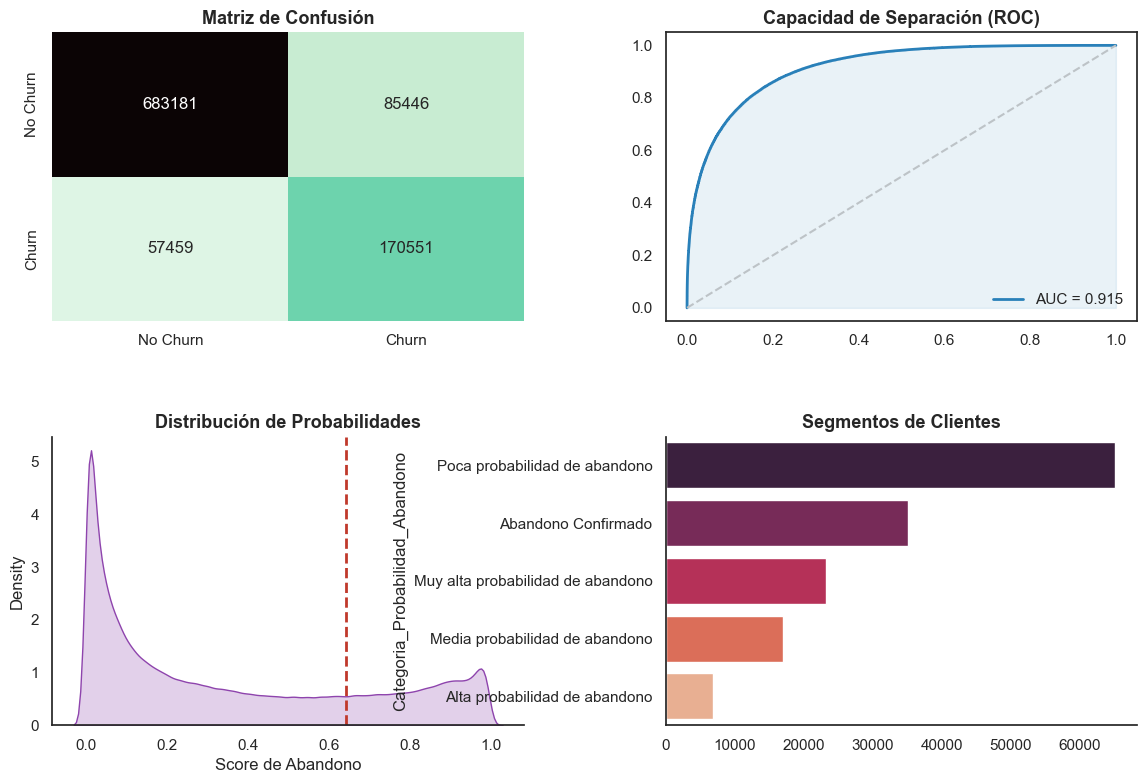


🔍 Analizando impacto de variables (SHAP)...


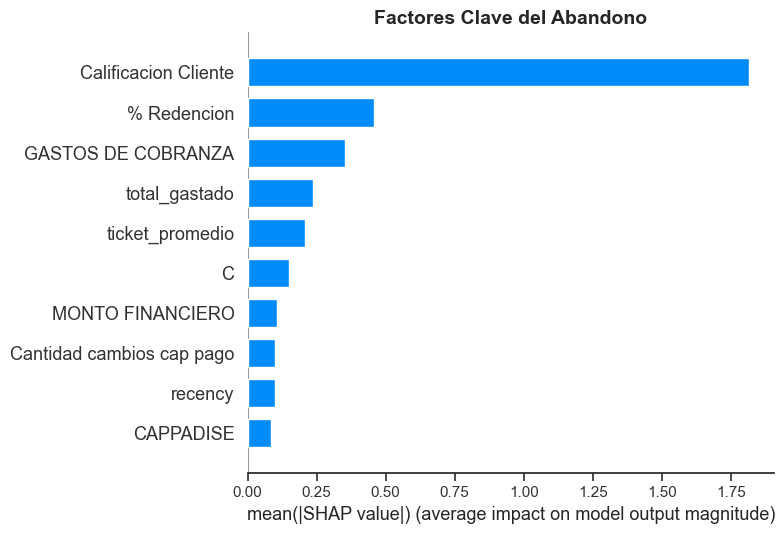


····························································
✅ VISUALIZACIÓN FINALIZADA


In [2]:
# =================================================MA
# CELDA DE VISUALIZACIÓN ESTILIZADA Y COMPACTA
# =================================================

import seaborn as sns
from sklearn.metrics import roc_curve, auc
import shap

# 1. CONFIGURACIÓN DE ESTILO (Minimalista)
sns.set_theme(style="white", context="notebook") # Contexto más pequeño que 'talk'
custom_colors = ["#34495e", "#3498db", "#95a5a6", "#e74c3c", "#2ecc71"]
sns.set_palette(custom_colors)

# --- A. RESUMEN EN TEXTO PARA IA ---
print("\n" + "·"*60)
print("📊 ESTADÍSTICAS")
print("·"*60)

report = classification_report(y_churn_test, y_churn_pred_optimal, output_dict=True)
cm = confusion_matrix(y_churn_test, y_churn_pred_optimal)
total_clientes = len(predicciones_completas_df)
con_riesgo = predicciones_completas_df[predicciones_completas_df['Prediccion_Churn'] == 1]

resumen_llm = f"""
MODEL PERFORMANCE:
- ROC AUC: {roc_auc_score(y_churn_test, y_churn_proba):.4f} | F1: {report['1']['f1-score']:.4f}
- Precision: {report['1']['precision']:.4f} | Recall: {report['1']['recall']:.4f}
- Umbral: {umbral_optimo:.4f}

PORTFOLIO STATUS:
- Total: {total_clientes:,} | Riesgo Detectado: {len(con_riesgo):,} ({(len(con_riesgo)/total_clientes)*100:.1f}%)
- Segmentos: {predicciones_completas_df['Categoria_Probabilidad_Abandono'].value_counts(normalize=True).to_dict()}
"""
print(resumen_llm)

# --- B. PANEL DE GRÁFICAS ESTILIZADAS ---
# Tamaño reducido a 14x9 para que quepa bien en pantalla
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Matriz de Confusión (Limpia)
sns.heatmap(cm, annot=True, fmt='d', cmap='mako_r', ax=axes[0,0], cbar=False,
            annot_kws={"size": 12}, xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[0,0].set_title('Matriz de Confusión', fontsize=13, weight='bold')

# 2. Curva ROC (Estilizada)
fpr, tpr, _ = roc_curve(y_churn_test, y_churn_proba)
axes[0,1].plot(fpr, tpr, color='#2980b9', lw=2, label=f'AUC = {auc(fpr, tpr):.3f}')
axes[0,1].fill_between(fpr, tpr, alpha=0.1, color='#2980b9')
axes[0,1].plot([0, 1], [0, 1], color='#bdc3c7', linestyle='--')
axes[0,1].set_title('Capacidad de Separación (ROC)', fontsize=13, weight='bold')
axes[0,1].legend(loc="lower right", frameon=False)

# 3. Distribución de Riesgo (Sin bordes)
sns.kdeplot(y_churn_proba, fill=True, color='#8e44ad', ax=axes[1,0], bw_adjust=0.5)
axes[1,0].axvline(umbral_optimo, color='#c0392b', linestyle='--', lw=2, label=f'Umbral')
axes[1,0].set_title('Distribución de Probabilidades', fontsize=13, weight='bold')
axes[1,0].set_xlabel('Score de Abandono')
sns.despine(ax=axes[1,0])

# 4. Segmentación (Barras Horizontales Estilizadas)
data_cat = predicciones_completas_df['Categoria_Probabilidad_Abandono'].value_counts()
sns.barplot(x=data_cat.values, y=data_cat.index, palette='rocket', ax=axes[1,1])
axes[1,1].set_title('Segmentos de Clientes', fontsize=13, weight='bold')
sns.despine(ax=axes[1,1])

plt.show()

# --- C. EXPLICABILIDAD (SHAP) COMPACTA ---
print("\n🔍 Analizando impacto de variables (SHAP)...")
sample_size = min(1000, len(X_test_scaled_df)) # Muestra más pequeña para velocidad
X_sample = X_test_scaled_df.sample(sample_size, random_state=42)
explainer = shap.TreeExplainer(churn_model)
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(10, 5))
plt.title("Factores Clave del Abandono", fontsize=14, weight='bold')
shap.summary_plot(shap_values, X_sample, plot_type="bar", max_display=10, show=False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

print("\n" + "·"*60)
print("✅ VISUALIZACIÓN FINALIZADA")

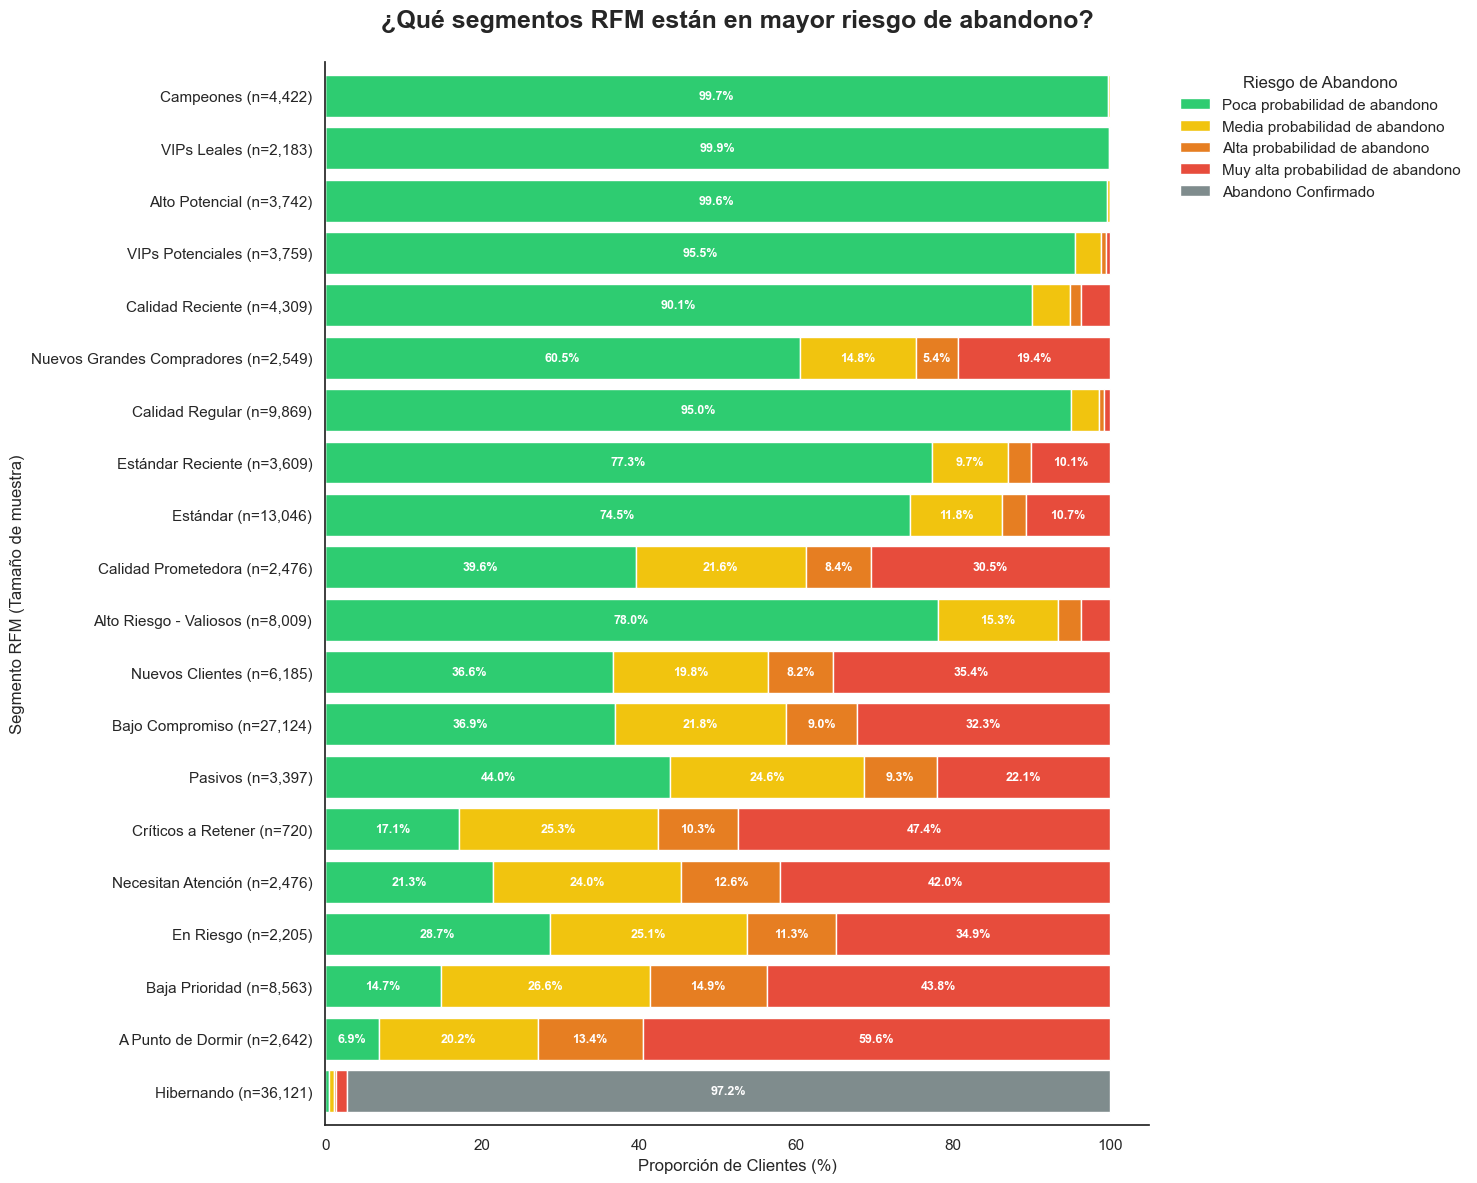

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    # 1. CARGA Y LIMPIEZA DE CARACTERES
    df_rfm = pd.read_csv(r'\\compartido.lamarina.mx\Inteligencia de Clientes\ICCM\Proyectos de Inteligencia\P001.- VFR\Dataframes LM\Segmentos VFR.csv', encoding='latin1')
    
    # Función para arreglar acentos rotos comunes
    def limpiar_texto(texto):
        if not isinstance(texto, str): return texto
        reemplazos = {
            'Ã¡': 'á', 'Ã©': 'é', 'Ã­': 'í', 'Ã³': 'ó', 'Ãº': 'ú',
            'Ã±': 'ñ', 'Ã': 'A', 'Â': '', 'Ã³n': 'ón', 'AtenciÃ³n': 'Atención'
        }
        for busca, cambia in reemplazos.items():
            texto = texto.replace(busca, cambia)
        return texto

    df_rfm['Segmento_RFM'] = df_rfm['Segmento_RFM'].apply(limpiar_texto)

    # 2. MERGE Y PREPARACIÓN
    df_viz = pd.merge(
        predicciones_completas_df,
        df_rfm[['CUENTA', 'Segmento_RFM']].drop_duplicates(),
        on='CUENTA',
        how='left'
    )
    df_viz['Segmento_RFM'] = df_viz['Segmento_RFM'].fillna('Desconocido')

    # 3. CONTAR CLIENTES POR SEGMENTO
    counts = df_viz['Segmento_RFM'].value_counts().to_dict()

    # 4. DICCIONARIO DE ORDEN (Nombres ya limpios)
    orden_segmentos = [
        'Campeones', 'VIPs Leales', 'Alto Potencial', 'VIPs Potenciales', 
        'Calidad Reciente', 'Nuevos Grandes Compradores', 'Calidad Regular', 
        'Estándar Reciente', 'Estándar', 'Calidad Prometedora', 
        'Alto Riesgo - Valiosos', 'Nuevos Clientes', 'Bajo Compromiso', 
        'Pasivos', 'Críticos a Retener', 'Necesitan Atención', 
        'En Riesgo', 'Baja Prioridad', 'A Punto de Dormir', 
        'Hibernando', 'Desconocido'
    ]

    # 5. CREAR ETIQUETAS CON TOTALES: "Nombre (n=123)"
    def get_label(seg):
        n = counts.get(seg, 0)
        return f"{seg} (n={n:,})"

    # Filtrar segmentos que existen en los datos
    existentes = [s for s in orden_segmentos if s in df_viz['Segmento_RFM'].unique()]
    
    # 6. TABLA CRUZADA (%)
    cross_tab = pd.crosstab(
        df_viz['Segmento_RFM'],
        df_viz['Categoria_Probabilidad_Abandono'],
        normalize='index'
    ) * 100

    # Reordenar filas y columnas
    cross_tab = cross_tab.reindex(existentes)
    col_order = [
        'Poca probabilidad de abandono',
        'Media probabilidad de abandono',
        'Alta probabilidad de abandono',
        'Muy alta probabilidad de abandono',
        'Abandono Confirmado'
    ]
    cross_tab = cross_tab[[c for c in col_order if c in cross_tab.columns]]

    # 7. GRÁFICO ESTILIZADO
    colors = {
        'Muy alta probabilidad de abandono': '#e74c3c', # Rojo fuerte
        'Alta probabilidad de abandono': '#e67e22',     # Naranja
        'Media probabilidad de abandono': '#f1c40f',    # Amarillo
        'Poca probabilidad de abandono': '#2ecc71',     # Verde
        'Abandono Confirmado': '#7f8c8d'                # Gris
    }

    ax = cross_tab.iloc[::-1].plot( # Invertir para que Campeones esté arriba
        kind='barh',
        stacked=True,
        figsize=(15, 12),
        width=0.8,
        color=[colors.get(c, '#bdc3c7') for c in cross_tab.columns]
    )

    # 8. PERSONALIZAR EJES
    nuevas_etiquetas = [get_label(s) for s in existentes[::-1]]
    ax.set_yticklabels(nuevas_etiquetas, fontsize=11)
    
    plt.title('¿Qué segmentos RFM están en mayor riesgo de abandono?', fontsize=18, pad=25, weight='bold')
    plt.xlabel('Proporción de Clientes (%)', fontsize=12)
    plt.ylabel('Segmento RFM (Tamaño de muestra)', fontsize=12)
    plt.legend(title='Riesgo de Abandono', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

    # 9. AÑADIR ETIQUETAS DE PORCENTAJE (Solo si son > 5%)
    for p in ax.patches:
        width = p.get_width()
        if width > 5:
            x = p.get_x() + width / 2
            y = p.get_y() + p.get_height() / 2
            ax.text(x, y, f'{width:.1f}%', ha='center', va='center', fontsize=9, color='white', weight='bold')

    sns.despine()
    plt.tight_layout()
    plt.show()

 
except Exception as e:
    print(f"Error detallado: {e}")

# Modelo de Abandono EB

In [3]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, 
                           roc_auc_score, accuracy_score, f1_score,
                           roc_curve, precision_recall_curve, auc)
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
from tqdm import tqdm
warnings.filterwarnings('ignore')
from joblib import Parallel, delayed
import multiprocessing
import shap

# --- Cargar datos y preprocesamiento inicial ---
in_path = r'.\Dataframes EB\Historico-CompraEB.csv'
df = pd.read_csv(in_path, encoding='latin-1', low_memory=False)

# Parseo de fechas
for date_col in ['Fecha', 'Max_Fecha', 'PRIMERA COMPRA']:
    if date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

# Convertir columnas object a numéricas si es posible
for col in df.columns:
    if df[col].dtype == 'object':
        tmp = df[col].astype(str).str.replace('%', '', regex=False).str.replace(',', '', regex=False)
        coerced = pd.to_numeric(tmp, errors='coerce')
        if coerced.notna().sum() > 0:
            df[col] = coerced

# Rellenar nulos
num_cols = df.select_dtypes(include=['number']).columns.tolist()
for c in num_cols:
    if df[c].isnull().any():
        mean_val = df[c].mean()
        df[c].fillna(mean_val, inplace=True)

obj_cols = df.select_dtypes(include=['object']).columns.tolist()
for c in obj_cols:
    if df[c].isnull().any():
        mode_series = df[c].mode(dropna=True)
        if not mode_series.empty:
            mode_val = mode_series.iloc[0]
            df[c].fillna(mode_val, inplace=True)
        else:
            df[c].fillna('missing', inplace=True)

# 1. PREPROCESAMIENTO INICIAL
print("1. PREPROCESAMIENTO INICIAL")

categorical_cols = ['EDOCIV', 'SEXO', 'NIVEL DE ESTUDIOS', 'PUESTO', 'TIPO EMPLEO', 
                   'TIPOCTANUM', 'RANGO DE EDAD', 'Departamento', 'Gpo de Artículo']

label_encoders = {}
for col in categorical_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

# 2. DEFINICIÓN DE VENTANAS TEMPORALES (CORREGIDO)
print("2. DEFINICIÓN DE VENTANAS TEMPORALES")

df = df.sort_values(['CUENTA', 'Fecha'])
observation_window_months = 12 
prediction_window_months = 9 

observation_window_days = observation_window_months * 30
prediction_window_days = prediction_window_months * 30

# --- NUEVA LÓGICA DE SELECCIÓN DE VENTANAS ---
n_ventanas_deseadas = 45  # <--- AQUÍ ELIGES EL NÚMERO DE VENTANAS (40, 50, etc.)

df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce").dt.normalize()
df = df.dropna(subset=["Fecha"]).copy()
unique_dates = pd.to_datetime(np.sort(df["Fecha"].unique())).to_pydatetime()

# Identificar todas las fechas de inicio posibles
# Una fecha es válida si permite una ventana completa de observación + predicción
valid_start_dates_indices = []
max_date = unique_dates.max()

for idx, start_date in enumerate(unique_dates):
    obs_end = start_date + timedelta(days=observation_window_days)
    pred_end = obs_end + timedelta(days=prediction_window_days)
    if pred_end <= max_date:
        valid_start_dates_indices.append(idx)

# Seleccionar índices de forma homogénea usando linspace
if len(valid_start_dates_indices) > n_ventanas_deseadas:
    selected_indices_pos = np.linspace(0, len(valid_start_dates_indices) - 1, n_ventanas_deseadas, dtype=int)
    indices = [valid_start_dates_indices[i] for i in selected_indices_pos]
else:
    indices = valid_start_dates_indices

print(f"Total fechas posibles: {len(valid_start_dates_indices)}")
print(f"Número de ventanas seleccionadas: {len(indices)}")

# 3. CONSTRUCCIÓN DE FEATURES Y TARGETS
print("3. CONSTRUCCIÓN DE FEATURES Y TARGETS")

def calculate_features(group):
    features = {}
    features['total_gastado'] = group['Vta Total'].sum()
    features['frecuencia_compra'] = group.shape[0]
    features['ticket_promedio'] = group['Vta Total'].mean()
    
    if group['Fecha'].nunique() > 1:
        features['recency'] = (group['Fecha'].max() - group['Fecha'].min()).days
    else:
        features['recency'] = 0

    features['std_gasto'] = group['Vta Total'].std() if group.shape[0] > 1 else 0
    features['cv_gasto'] = features['std_gasto'] / features['ticket_promedio'] if features['ticket_promedio'] > 0 else 0

    customer_cols = ['EDOCIV', 'SEXO', 'CAPPAGO', 'CAPPADIS', 'CAPPADISE', 'DIASVDO',
                    'NIVEL DE ESTUDIOS', 'PUESTO', 'Dependientes economicos', 
                    'Salario Mensual', 'Garantias', 'Devoluciones', 'PAGO',
                    'MORA ACUMULADO', 'MONTO FINANCIERO', 'GASTOS DE COBRANZA',
                    'C', 'Cantidad cambios cap pago', 'Calificacion Cliente',
                    '% Redencion', 'TIPO EMPLEO', 'TIPOCTANUM', 'RANGO DE EDAD',
                    'Departamento']
    for col in customer_cols:
        if col in group.columns:
            features[col] = group[col].iloc[-1]
    return pd.Series(features)

def process_window_churn(i, unique_dates, observation_window_days, prediction_window_days, df_full):
    obs_start = unique_dates[i]
    obs_end = obs_start + timedelta(days=observation_window_days)
    pred_start = obs_end + timedelta(days=1)
    pred_end = pred_start + timedelta(days=prediction_window_days)

    obs_data = df_full[(df_full['Fecha'] >= obs_start) & (df_full['Fecha'] <= obs_end)]
    active_customers_in_obs = obs_data['CUENTA'].unique()
    
    pred_data = df_full[
        (df_full['Fecha'] >= pred_start) & 
        (df_full['Fecha'] <= pred_end) & 
        (df_full['CUENTA'].isin(active_customers_in_obs))
    ]

    features_df = obs_data.groupby('CUENTA').apply(calculate_features).reset_index()
    customers_who_bought_in_pred = pred_data['CUENTA'].unique()
    
    features_df['churn'] = features_df['CUENTA'].apply(lambda x: 0 if x in customers_who_bought_in_pred else 1)
    features_df['periodo'] = i
    
    return features_df

n_jobs = multiprocessing.cpu_count() - 2 

all_samples = Parallel(n_jobs=n_jobs)(
    delayed(process_window_churn)(i, unique_dates, observation_window_days, prediction_window_days, df)
    for i in tqdm(indices, desc=f"Procesando {len(indices)} ventanas", unit="ventana")
)

final_df = pd.concat(all_samples, ignore_index=True)

# 4. PREPARACIÓN DE DATOS PARA MODELADO
print("4. PREPARACIÓN DE DATOS PARA MODELADO")
final_df.dropna(subset=['churn'], inplace=True)

X = final_df.drop(['CUENTA', 'periodo', 'churn'], axis=1)
y_churn = final_df['churn'].astype(int)

X = X.loc[:, X.nunique() > 1]
X.dropna(axis=1, how='all', inplace=True)

X_train, X_test, y_churn_train, y_churn_test = train_test_split(
    X, y_churn, test_size=0.2, random_state=42, stratify=y_churn
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# 5. ENTRENAMIENTO DE MODELO DE CHURN
print("5. ENTRENAMIENTO DE MODELO DE CHURN")

neg_count = y_churn_train.value_counts()[0]
pos_count = y_churn_train.value_counts()[1]
scale_pos_weight_value = neg_count / pos_count if pos_count > 0 else 1

churn_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight_value,
    random_state=42,
    eval_metric='aucpr',
    use_label_encoder=False 
)
churn_model.fit(X_train_scaled_df, y_churn_train)

# 6. EVALUACIÓN DE MODELO DE CHURN
print("6. EVALUACIÓN DE MODELO DE CHURN")
y_churn_proba = churn_model.predict_proba(X_test_scaled_df)[:, 1]

def find_optimal_threshold(y_true, y_proba):
    thresholds = np.linspace(0.01, 0.99, 100)
    f1_scores = [f1_score(y_true, (y_proba >= t).astype(int)) for t in thresholds]
    optimal_idx = np.argmax(f1_scores)
    return thresholds[optimal_idx], f1_scores[optimal_idx]

umbral_optimo, f1_optimo = find_optimal_threshold(y_churn_test, y_churn_proba)
y_churn_pred_optimal = (y_churn_proba >= umbral_optimo).astype(int)

print(f"\n--- DESEMPEÑO ---")
print(f"ROC AUC: {roc_auc_score(y_churn_test, y_churn_proba):.4f}")
print(classification_report(y_churn_test, y_churn_pred_optimal))

# 7. PREDICCIÓN FUTURA Y CATEGORIZACIÓN
print("\n7. ASIGNACIÓN DE CATEGORÍAS")

current_date = df['Fecha'].max()
obs_window_start_future = current_date - timedelta(days=observation_window_days)
current_obs_data = df[df['Fecha'] >= obs_window_start_future]

current_features = current_obs_data.groupby('CUENTA').apply(calculate_features).reset_index()
X_current = current_features.drop('CUENTA', axis=1)

# Alinear columnas
for c in set(X_train.columns) - set(X_current.columns): X_current[c] = 0
X_current = X_current[X_train.columns]

X_current_scaled = scaler.transform(X_current)
proba_churn_future = churn_model.predict_proba(X_current_scaled)[:, 1]

future_predictions_df = pd.DataFrame({
    'CUENTA': current_features['CUENTA'],
    'Probabilidad_Churn': proba_churn_future,
    'Prediccion_Churn': (proba_churn_future >= umbral_optimo).astype(int)
})

def assign_churn_category(prob, umbral):
    if prob < umbral * 0.5: return 'Poca probabilidad de abandono'
    elif prob < umbral * 0.85: return 'Media probabilidad de abandono'
    elif prob < umbral: return 'Alta probabilidad de abandono'
    else: return 'Muy alta probabilidad de abandono'

future_predictions_df['Categoria_Probabilidad_Abandono'] = future_predictions_df['Probabilidad_Churn'].apply(
    lambda x: assign_churn_category(x, umbral_optimo)
)

# Agregar clientes que ya tienen más de 12 meses sin comprar (Abandono confirmado)
todos_los_clientes = df['CUENTA'].unique()
clientes_con_prediccion = future_predictions_df['CUENTA'].unique()
clientes_sin_prediccion = list(set(todos_los_clientes) - set(clientes_con_prediccion))

abandono_confirmado_df = pd.DataFrame({
    'CUENTA': clientes_sin_prediccion,
    'Probabilidad_Churn': 1.0,
    'Prediccion_Churn': 1,
    'Categoria_Probabilidad_Abandono': 'Abandono Confirmado'
})

predicciones_completas_df = pd.concat([future_predictions_df, abandono_confirmado_df], ignore_index=True)
predicciones_completas_df['Umbral_Optimo_Churn'] = umbral_optimo

predicciones_completas_df.to_csv(r'.\Dataframes EB\ClientesChurnEB.csv', index=False, encoding='utf-8-sig')

print("\nANÁLISIS DE CHURN COMPLETADO EXITOSAMENTE!")

1. PREPROCESAMIENTO INICIAL
2. DEFINICIÓN DE VENTANAS TEMPORALES
Total fechas posibles: 463
Número de ventanas seleccionadas: 45
3. CONSTRUCCIÓN DE FEATURES Y TARGETS


Procesando 45 ventanas: 100%|██████████| 45/45 [02:36<00:00,  3.48s/ventana]


4. PREPARACIÓN DE DATOS PARA MODELADO
5. ENTRENAMIENTO DE MODELO DE CHURN
6. EVALUACIÓN DE MODELO DE CHURN

--- DESEMPEÑO ---
ROC AUC: 0.8910
              precision    recall  f1-score   support

           0       0.80      0.74      0.77    679760
           1       0.80      0.85      0.82    843113

    accuracy                           0.80   1522873
   macro avg       0.80      0.79      0.80   1522873
weighted avg       0.80      0.80      0.80   1522873


7. ASIGNACIÓN DE CATEGORÍAS

ANÁLISIS DE CHURN COMPLETADO EXITOSAMENTE!



····························································
📊 ESTADÍSTICAS
····························································

MODEL PERFORMANCE:
- ROC AUC: 0.8910 | F1: 0.8245
- Precision: 0.8001 | Recall: 0.8504
- Umbral: 0.3664

PORTFOLIO STATUS:
- Total: 313,915 | Riesgo Detectado: 226,690 (72.2%)
- Segmentos: {'Abandono Confirmado': 0.4589012949365274, 'Muy alta probabilidad de abandono': 0.2632368634821528, 'Poca probabilidad de abandono': 0.13948361817689503, 'Media probabilidad de abandono': 0.10171224694582928, 'Alta probabilidad de abandono': 0.03666597645859548}



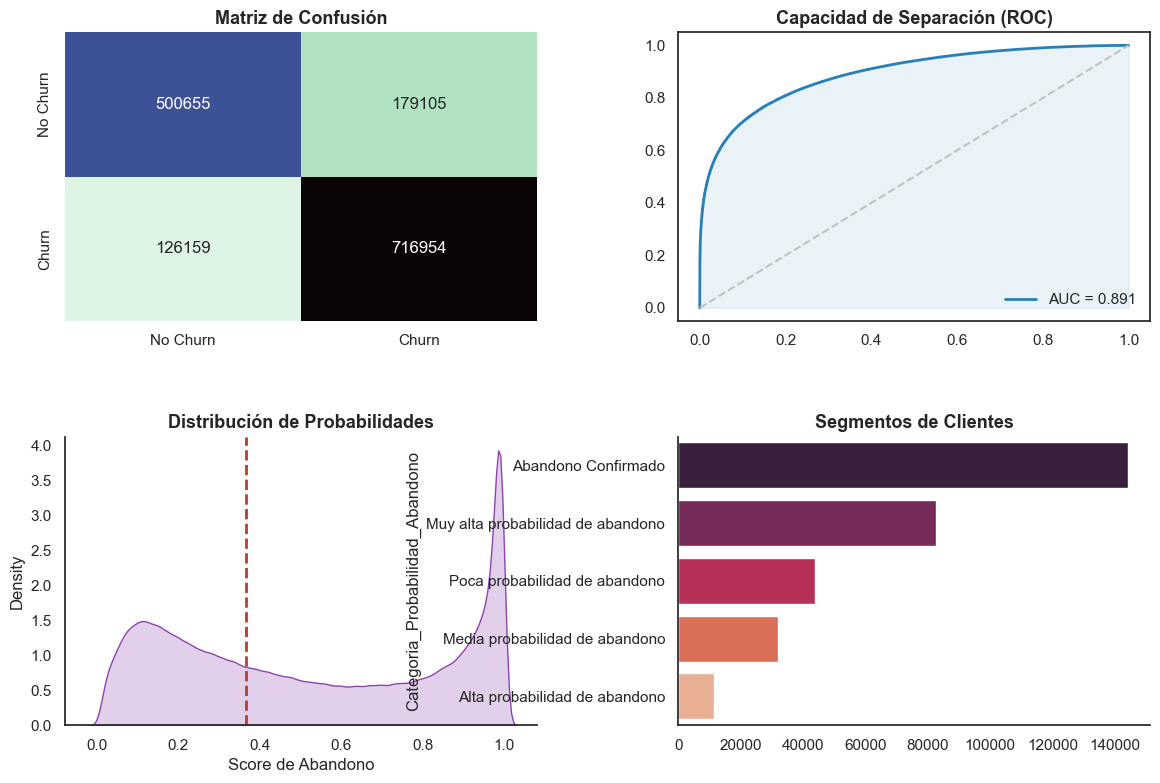


🔍 Analizando impacto de variables (SHAP)...


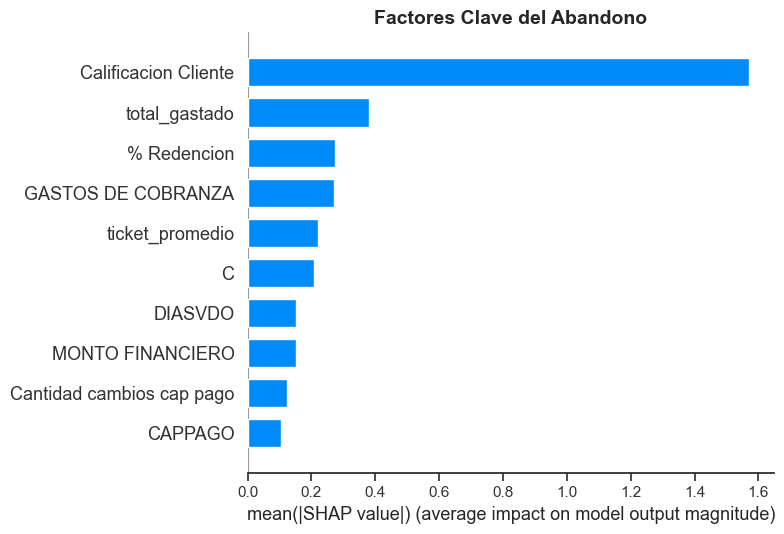


····························································
✅ VISUALIZACIÓN FINALIZADA


In [4]:

import seaborn as sns
from sklearn.metrics import roc_curve, auc
import shap

# 1. CONFIGURACIÓN DE ESTILO (Minimalista)
sns.set_theme(style="white", context="notebook") # Contexto más pequeño que 'talk'
custom_colors = ["#34495e", "#3498db", "#95a5a6", "#e74c3c", "#2ecc71"]
sns.set_palette(custom_colors)

# --- A. RESUMEN EN TEXTO PARA IA ---
print("\n" + "·"*60)
print("📊 ESTADÍSTICAS")
print("·"*60)

report = classification_report(y_churn_test, y_churn_pred_optimal, output_dict=True)
cm = confusion_matrix(y_churn_test, y_churn_pred_optimal)
total_clientes = len(predicciones_completas_df)
con_riesgo = predicciones_completas_df[predicciones_completas_df['Prediccion_Churn'] == 1]

resumen_llm = f"""
MODEL PERFORMANCE:
- ROC AUC: {roc_auc_score(y_churn_test, y_churn_proba):.4f} | F1: {report['1']['f1-score']:.4f}
- Precision: {report['1']['precision']:.4f} | Recall: {report['1']['recall']:.4f}
- Umbral: {umbral_optimo:.4f}

PORTFOLIO STATUS:
- Total: {total_clientes:,} | Riesgo Detectado: {len(con_riesgo):,} ({(len(con_riesgo)/total_clientes)*100:.1f}%)
- Segmentos: {predicciones_completas_df['Categoria_Probabilidad_Abandono'].value_counts(normalize=True).to_dict()}
"""
print(resumen_llm)

# --- B. PANEL DE GRÁFICAS ESTILIZADAS ---
# Tamaño reducido a 14x9 para que quepa bien en pantalla
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Matriz de Confusión (Limpia)
sns.heatmap(cm, annot=True, fmt='d', cmap='mako_r', ax=axes[0,0], cbar=False,
            annot_kws={"size": 12}, xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[0,0].set_title('Matriz de Confusión', fontsize=13, weight='bold')

# 2. Curva ROC (Estilizada)
fpr, tpr, _ = roc_curve(y_churn_test, y_churn_proba)
axes[0,1].plot(fpr, tpr, color='#2980b9', lw=2, label=f'AUC = {auc(fpr, tpr):.3f}')
axes[0,1].fill_between(fpr, tpr, alpha=0.1, color='#2980b9')
axes[0,1].plot([0, 1], [0, 1], color='#bdc3c7', linestyle='--')
axes[0,1].set_title('Capacidad de Separación (ROC)', fontsize=13, weight='bold')
axes[0,1].legend(loc="lower right", frameon=False)

# 3. Distribución de Riesgo (Sin bordes)
sns.kdeplot(y_churn_proba, fill=True, color='#8e44ad', ax=axes[1,0], bw_adjust=0.5)
axes[1,0].axvline(umbral_optimo, color='#c0392b', linestyle='--', lw=2, label=f'Umbral')
axes[1,0].set_title('Distribución de Probabilidades', fontsize=13, weight='bold')
axes[1,0].set_xlabel('Score de Abandono')
sns.despine(ax=axes[1,0])

# 4. Segmentación (Barras Horizontales Estilizadas)
data_cat = predicciones_completas_df['Categoria_Probabilidad_Abandono'].value_counts()
sns.barplot(x=data_cat.values, y=data_cat.index, palette='rocket', ax=axes[1,1])
axes[1,1].set_title('Segmentos de Clientes', fontsize=13, weight='bold')
sns.despine(ax=axes[1,1])

plt.show()

# --- C. EXPLICABILIDAD (SHAP) COMPACTA ---
print("\n🔍 Analizando impacto de variables (SHAP)...")
sample_size = min(1000, len(X_test_scaled_df)) # Muestra más pequeña para velocidad
X_sample = X_test_scaled_df.sample(sample_size, random_state=42)
explainer = shap.TreeExplainer(churn_model)
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(10, 5))
plt.title("Factores Clave del Abandono", fontsize=14, weight='bold')
shap.summary_plot(shap_values, X_sample, plot_type="bar", max_display=10, show=False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

print("\n" + "·"*60)
print("✅ VISUALIZACIÓN FINALIZADA")

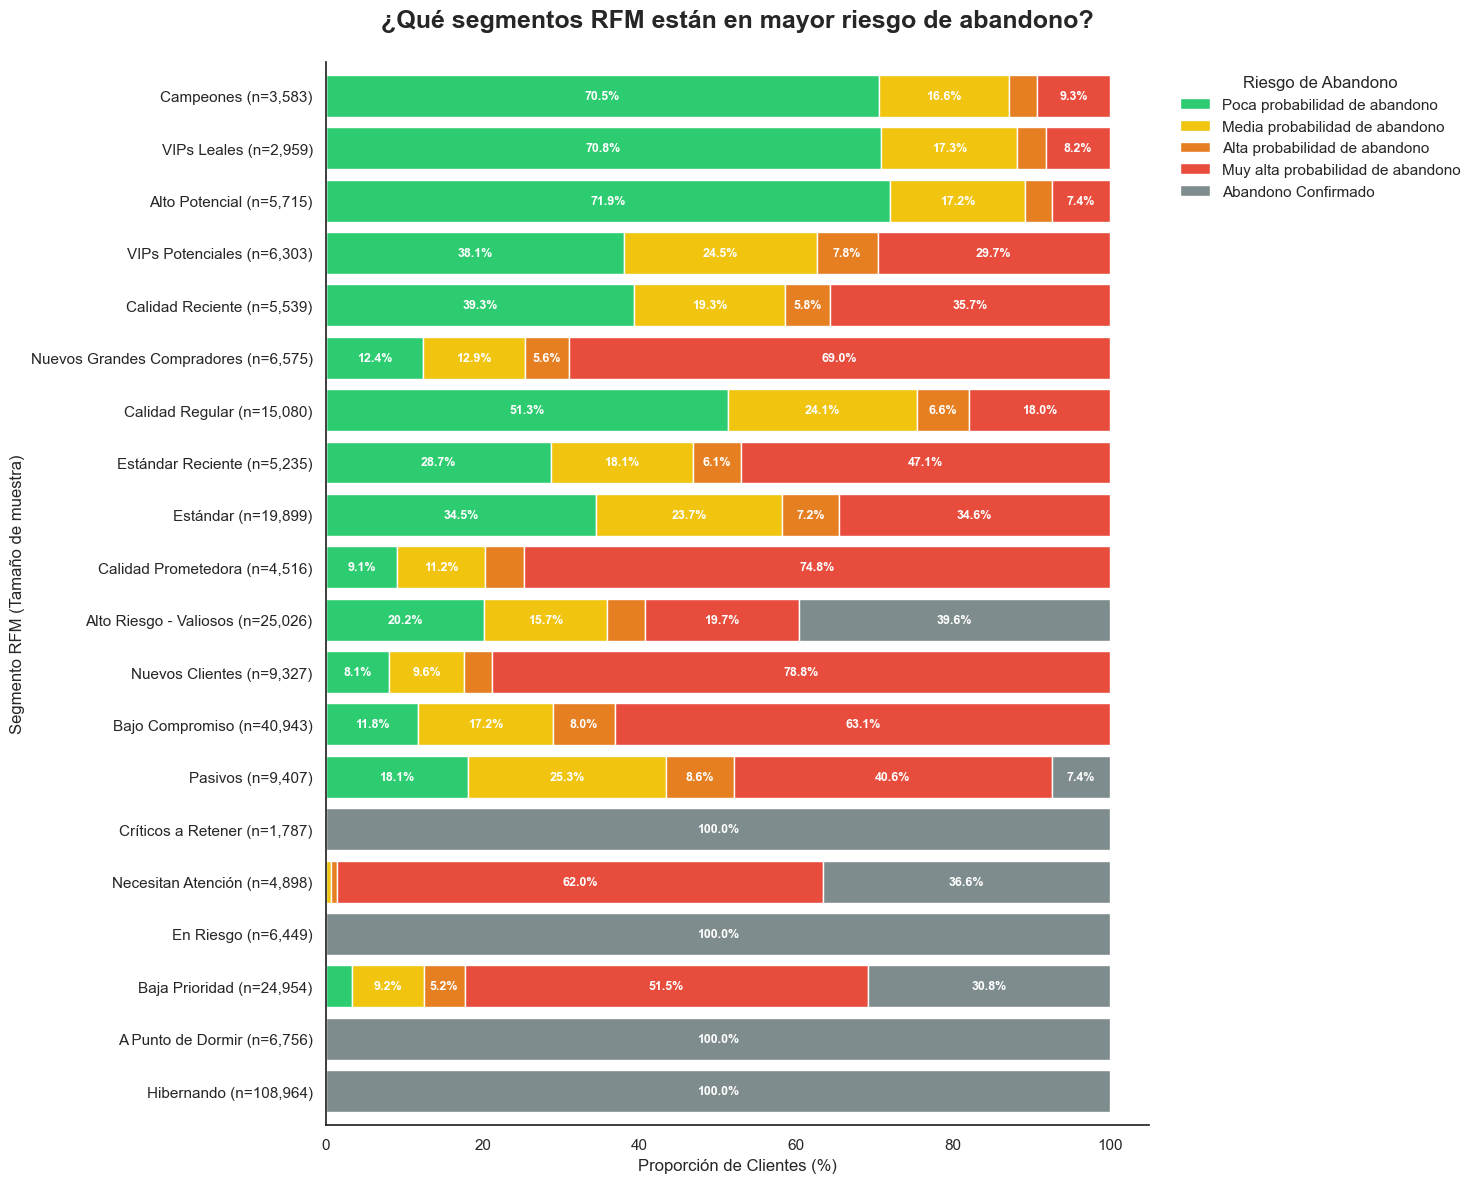

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    # 1. CARGA Y LIMPIEZA DE CARACTERES
    df_rfm = pd.read_csv(r'\\compartido.lamarina.mx\Inteligencia de Clientes\ICCM\Proyectos de Inteligencia\P001.- VFR\Dataframes EB\Segmentos VFR.csv', encoding='latin1')
    
    # Función para arreglar acentos rotos comunes
    def limpiar_texto(texto):
        if not isinstance(texto, str): return texto
        reemplazos = {
            'Ã¡': 'á', 'Ã©': 'é', 'Ã­': 'í', 'Ã³': 'ó', 'Ãº': 'ú',
            'Ã±': 'ñ', 'Ã': 'A', 'Â': '', 'Ã³n': 'ón', 'AtenciÃ³n': 'Atención'
        }
        for busca, cambia in reemplazos.items():
            texto = texto.replace(busca, cambia)
        return texto

    df_rfm['Segmento_RFM'] = df_rfm['Segmento_RFM'].apply(limpiar_texto)

    # 2. MERGE Y PREPARACIÓN
    df_viz = pd.merge(
        predicciones_completas_df,
        df_rfm[['CUENTA', 'Segmento_RFM']].drop_duplicates(),
        on='CUENTA',
        how='left'
    )
    df_viz['Segmento_RFM'] = df_viz['Segmento_RFM'].fillna('Desconocido')

    # 3. CONTAR CLIENTES POR SEGMENTO
    counts = df_viz['Segmento_RFM'].value_counts().to_dict()

    # 4. DICCIONARIO DE ORDEN (Nombres ya limpios)
    orden_segmentos = [
        'Campeones', 'VIPs Leales', 'Alto Potencial', 'VIPs Potenciales', 
        'Calidad Reciente', 'Nuevos Grandes Compradores', 'Calidad Regular', 
        'Estándar Reciente', 'Estándar', 'Calidad Prometedora', 
        'Alto Riesgo - Valiosos', 'Nuevos Clientes', 'Bajo Compromiso', 
        'Pasivos', 'Críticos a Retener', 'Necesitan Atención', 
        'En Riesgo', 'Baja Prioridad', 'A Punto de Dormir', 
        'Hibernando', 'Desconocido'
    ]

    # 5. CREAR ETIQUETAS CON TOTALES: "Nombre (n=123)"
    def get_label(seg):
        n = counts.get(seg, 0)
        return f"{seg} (n={n:,})"

    # Filtrar segmentos que existen en los datos
    existentes = [s for s in orden_segmentos if s in df_viz['Segmento_RFM'].unique()]
    
    # 6. TABLA CRUZADA (%)
    cross_tab = pd.crosstab(
        df_viz['Segmento_RFM'],
        df_viz['Categoria_Probabilidad_Abandono'],
        normalize='index'
    ) * 100

    # Reordenar filas y columnas
    cross_tab = cross_tab.reindex(existentes)
    col_order = [
        'Poca probabilidad de abandono',
        'Media probabilidad de abandono',
        'Alta probabilidad de abandono',
        'Muy alta probabilidad de abandono',
        'Abandono Confirmado'
    ]
    cross_tab = cross_tab[[c for c in col_order if c in cross_tab.columns]]

    # 7. GRÁFICO ESTILIZADO
    colors = {
        'Muy alta probabilidad de abandono': '#e74c3c', # Rojo fuerte
        'Alta probabilidad de abandono': '#e67e22',     # Naranja
        'Media probabilidad de abandono': '#f1c40f',    # Amarillo
        'Poca probabilidad de abandono': '#2ecc71',     # Verde
        'Abandono Confirmado': '#7f8c8d'                # Gris
    }

    ax = cross_tab.iloc[::-1].plot( # Invertir para que Campeones esté arriba
        kind='barh',
        stacked=True,
        figsize=(15, 12),
        width=0.8,
        color=[colors.get(c, '#bdc3c7') for c in cross_tab.columns]
    )

    # 8. PERSONALIZAR EJES
    nuevas_etiquetas = [get_label(s) for s in existentes[::-1]]
    ax.set_yticklabels(nuevas_etiquetas, fontsize=11)
    
    plt.title('¿Qué segmentos RFM están en mayor riesgo de abandono?', fontsize=18, pad=25, weight='bold')
    plt.xlabel('Proporción de Clientes (%)', fontsize=12)
    plt.ylabel('Segmento RFM (Tamaño de muestra)', fontsize=12)
    plt.legend(title='Riesgo de Abandono', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

    # 9. AÑADIR ETIQUETAS DE PORCENTAJE (Solo si son > 5%)
    for p in ax.patches:
        width = p.get_width()
        if width > 5:
            x = p.get_x() + width / 2
            y = p.get_y() + p.get_height() / 2
            ax.text(x, y, f'{width:.1f}%', ha='center', va='center', fontsize=9, color='white', weight='bold')

    sns.despine()
    plt.tight_layout()
    plt.show()

 
except Exception as e:
    print(f"Error detallado: {e}")

# Unir Churn con Quintiles

In [5]:
import pandas as pd

# Leer los archivos de entrada
df1 = pd.read_csv('.\\Dataframes LM\\ClientesChurnLM.csv', encoding='utf-8-sig')
df2 = pd.read_csv('.\\Dataframes EB\\ClientesChurnEB.csv', encoding='utf-8-sig')

# Agregar columna NEGOCIO
df1['NEGOCIO'] = 1
df2['NEGOCIO'] = 5

# Columnas necesarias para unir
selected_cols = [
    'CUENTA',
    'NEGOCIO',
    'Probabilidad_Churn',
    'Prediccion_Churn',
    'Categoria_Probabilidad_Abandono',
    'Umbral_Optimo_Churn'
]

# Filtrar columnas
df1_selected = df1[selected_cols]
df2_selected = df2[selected_cols]

# Unir ambos dataframes de predicciones
combined_df = pd.concat([df1_selected, df2_selected], ignore_index=True)

# Leer el archivo original (Quintiles.csv)
output_path = r'\\compartido.lamarina.mx\Inteligencia de Clientes\Bases de datos\Quintiles.csv'
original_df = pd.read_csv(output_path, encoding='utf-8-sig')

# --- CAMBIO IMPORTANTE: Limpiar columnas viejas si existen ---
# Definimos las columnas que queremos actualizar
cols_to_update = [
    'Probabilidad_Churn', 
    'Prediccion_Churn', 
    'Categoria_Probabilidad_Abandono', 
    'Umbral_Optimo_Churn'
]

# Si alguna de estas columnas ya existe en el original, las borramos para evitar el _x / _y
original_df = original_df.drop(columns=[c for c in cols_to_update if c in original_df.columns])

# Ahora hacemos el merge limpio
merged_df = original_df.merge(
    combined_df,
    on=['CUENTA', 'NEGOCIO'],
    how='left'
)

# Rellenar valores faltantes con "Dato no disponible" (para cuentas que no están en el modelo)
merged_df['Categoria_Probabilidad_Abandono'] = merged_df['Categoria_Probabilidad_Abandono'].fillna("Dato no disponible")

# Guardar el archivo actualizado
merged_df.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"Columnas actualizadas correctamente en {output_path}")

Columnas actualizadas correctamente en \\compartido.lamarina.mx\Inteligencia de Clientes\Bases de datos\Quintiles.csv
